In [ ]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from scipy.stats import spearmanr

# repository dire
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
ROOT = next((p for p in candidates if (p / 'melodymap').exists() and (p / 'data').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Could not find project root.')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from melodymap.case_study import load_case_study, build_distance_table, summarize_case
from melodymap.simulation import generate_city, recover_association, run_simulation_lab, summarize_simulations
from melodymap.research_visualize import (
    plot_case_map,
    plot_distance_matrix,
    plot_sensor_reference,
    plot_simulation_panel,
)

CASE_DIR = ROOT / 'data' / 'case_study'
OUT_DIR = ROOT / 'outputs' / 'notebook'
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

CASE_RADIUS_M = 500
SIM_REPLICATES = 30
RANDOM_SEED = 2026

# print(f'Project root: {ROOT}')
# print(f'Notebook outputs: {OUT_DIR}')

# Melbourne Case Study
Music venue data come from the City of Melbourne’s Live Music Venues dataset, and pedestrian sensor locations come from the Pedestrian Counting System – Sensor Locations dataset. T

In [2]:
venues, sensors, sensor_stats = load_case_study(CASE_DIR)

print('Real venues')
display(venues)
print('Real pedestrian sensors')
display(sensors)
print('Published long-run pedestrian reference')
display(sensor_stats)

Real venues


,venue_name,venue_address,space_type,latitude,longitude,source
0,Sticky Institute,"Shop 10, Campbell Arcade, Melbourne, 3000",Bar,-37.817800,144.966083,City of Melbourne Live Music Venues
1,Curtin House,"Unit S15, Level 7, 252 Swanston Street, Melbou...",Bar,-37.811979,144.965134,City of Melbourne Live Music Venues
2,The Sub Club,"Unit 20, Basement, 35 Elizabeth Street, Melbou...",Unknown,-37.817392,144.964340,City of Melbourne Live Music Venues


Real pedestrian sensors


,location_id,sensor_description,sensor_name,latitude,longitude,status,source
0,2,Bourke Street Mall (South),Bou283_T,-37.813807,144.965167,A,City of Melbourne Pedestrian Counting System -...
1,4,Town Hall (West),Swa123_T,-37.814880,144.966088,A,City of Melbourne Pedestrian Counting System -...
2,6,Flinders Street Station Underpass,FliS_T,-37.819117,144.965583,A,City of Melbourne Pedestrian Counting System -...


Published long-run pedestrian reference


,location_id,sensor_description,mean_hourly_pedestrians,observation_count,period_note,source
0,2,Bourke Street Mall (South),887,131041,long-run hourly observations reported in publi...,Navon et al. / City of Melbourne pedestrian data
1,4,Town Hall (West),1277,131275,long-run hourly observations reported in publi...,Navon et al. / City of Melbourne pedestrian data
2,6,Flinders Street Station Underpass,1080,130762,long-run hourly observations reported in publi...,Navon et al. / City of Melbourne pedestrian data


## 1.1 Calculating Distances Between Music Venues and Pedestrian Sensors

In [3]:
distances = build_distance_table(venues, sensors, radius_m=CASE_RADIUS_M)
case_summary = summarize_case(venues, sensors, sensor_stats, radius_m=CASE_RADIUS_M)

distances.to_csv(OUT_DIR / 'case_study_distances.csv', index=False)
(OUT_DIR / 'case_study_summary.json').write_text(
    json.dumps(case_summary, indent=2, ensure_ascii=False), encoding='utf-8'
)

display(distances.sort_values(['venue_name', 'distance_m']))
print(json.dumps(case_summary, indent=2, ensure_ascii=False))

,venue_name,sensor_description,distance_m,within_radius
3,Curtin House,Bourke Street Mall (South),203.228598,True
4,Curtin House,Town Hall (West),333.252670,True
5,Curtin House,Flinders Street Station Underpass,794.672937,False
2,Sticky Institute,Flinders Street Station Underpass,152.860590,True
1,Sticky Institute,Town Hall (West),324.747041,True
0,Sticky Institute,Bourke Street Mall (South),451.307924,True
8,The Sub Club,Flinders Street Station Underpass,220.725951,True
7,The Sub Club,Town Hall (West),318.725989,True
6,The Sub Club,Bourke Street Mall (South),405.210065,True


{
  "n_venues": 3,
  "n_sensors": 3,
  "radius_m": 500.0,
  "n_links_within_radius": 8,
  "mean_sensors_within_radius_per_venue": 2.6666666666666665,
  "venues_with_multiple_candidate_sensors": 3,
  "median_nearest_sensor_distance_m": 203.2285979348585,
  "sensor_reference_mean_range": [
    887.0,
    1277.0
  ]
}


## 1.2 Visualizing Spatial Links Between Actual Venues and Sensors

The lines indicate candidate matches within 500 m. 



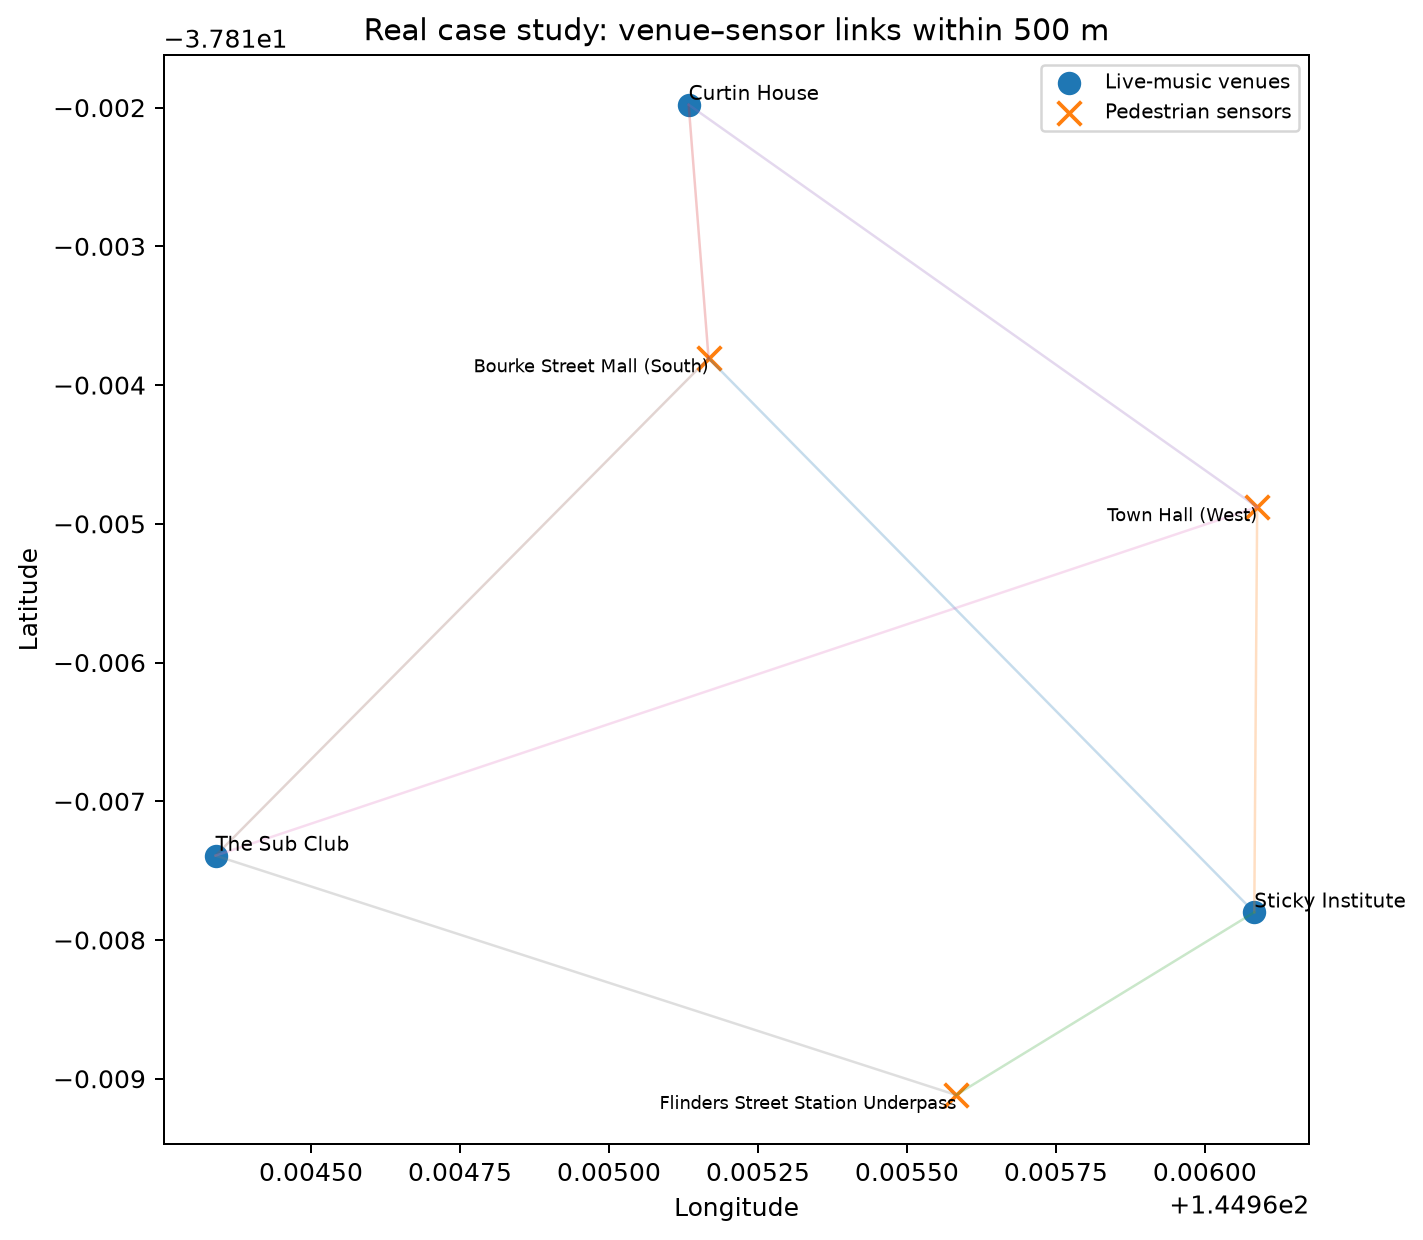

In [4]:
case_map_path = FIG_DIR / 'real_case_venue_sensor_links.png'
plot_case_map(venues, sensors, distances, case_map_path, radius_m=CASE_RADIUS_M)
display(Image(filename=str(case_map_path), width=760))

### 1.3 Visualizing the Distance Matrix

The distance matrix shows the distance from each venue to each of the three sensors. 

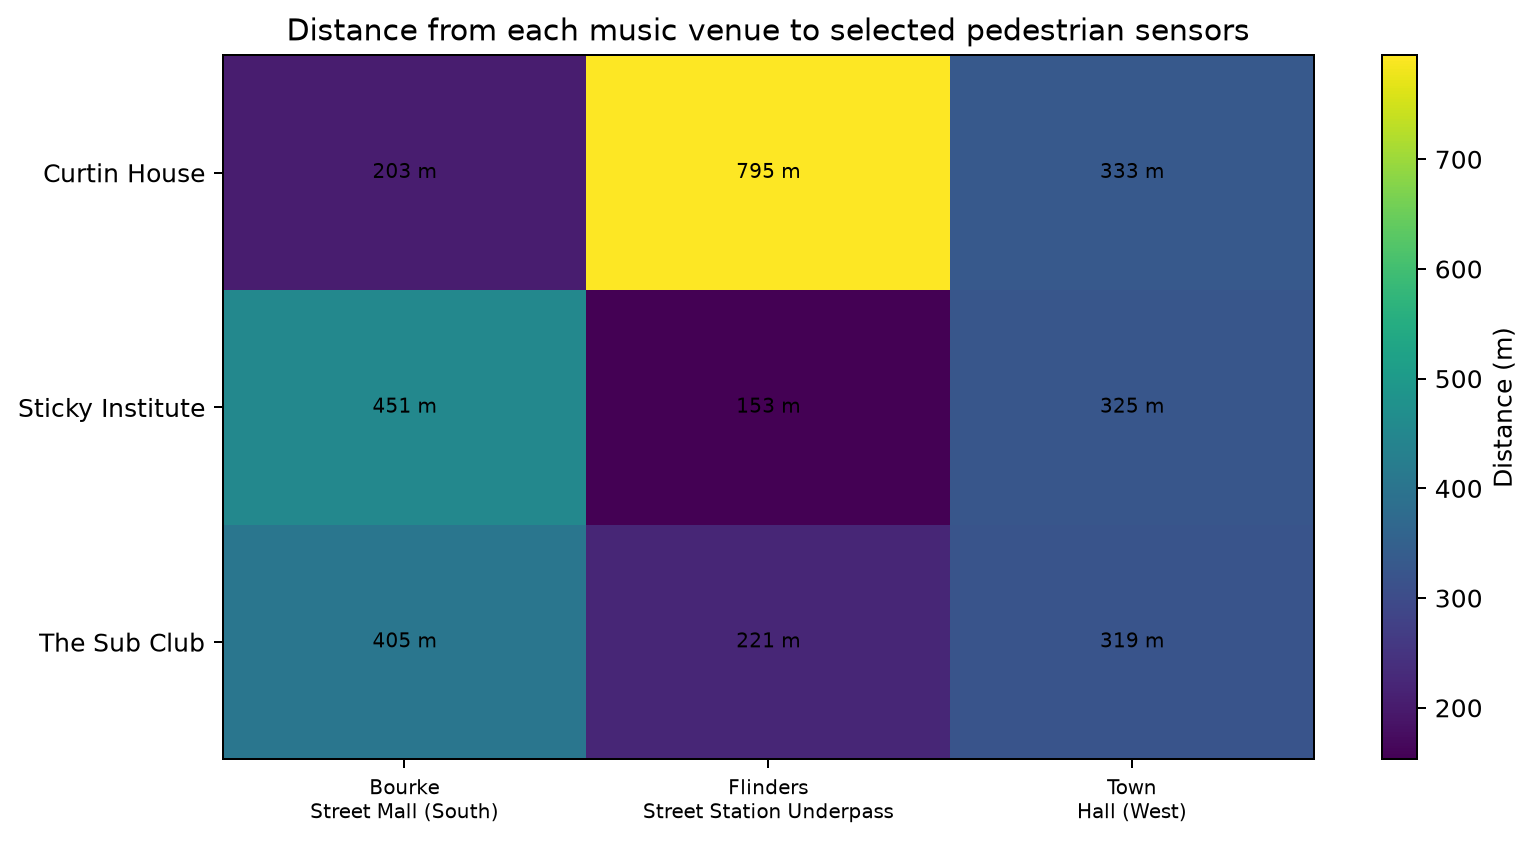

In [5]:
distance_matrix_path = FIG_DIR / 'real_case_distance_matrix.png'
plot_distance_matrix(distances, distance_matrix_path)
display(Image(filename=str(distance_matrix_path), width=820))

## 1.4 Visualizing Reference Levels of Observed Pedestrian Traffic

The figure below presents long-term average hourly pedestrian counts reported in published research, providing a reference for traffic levels at the three actual sensors. 

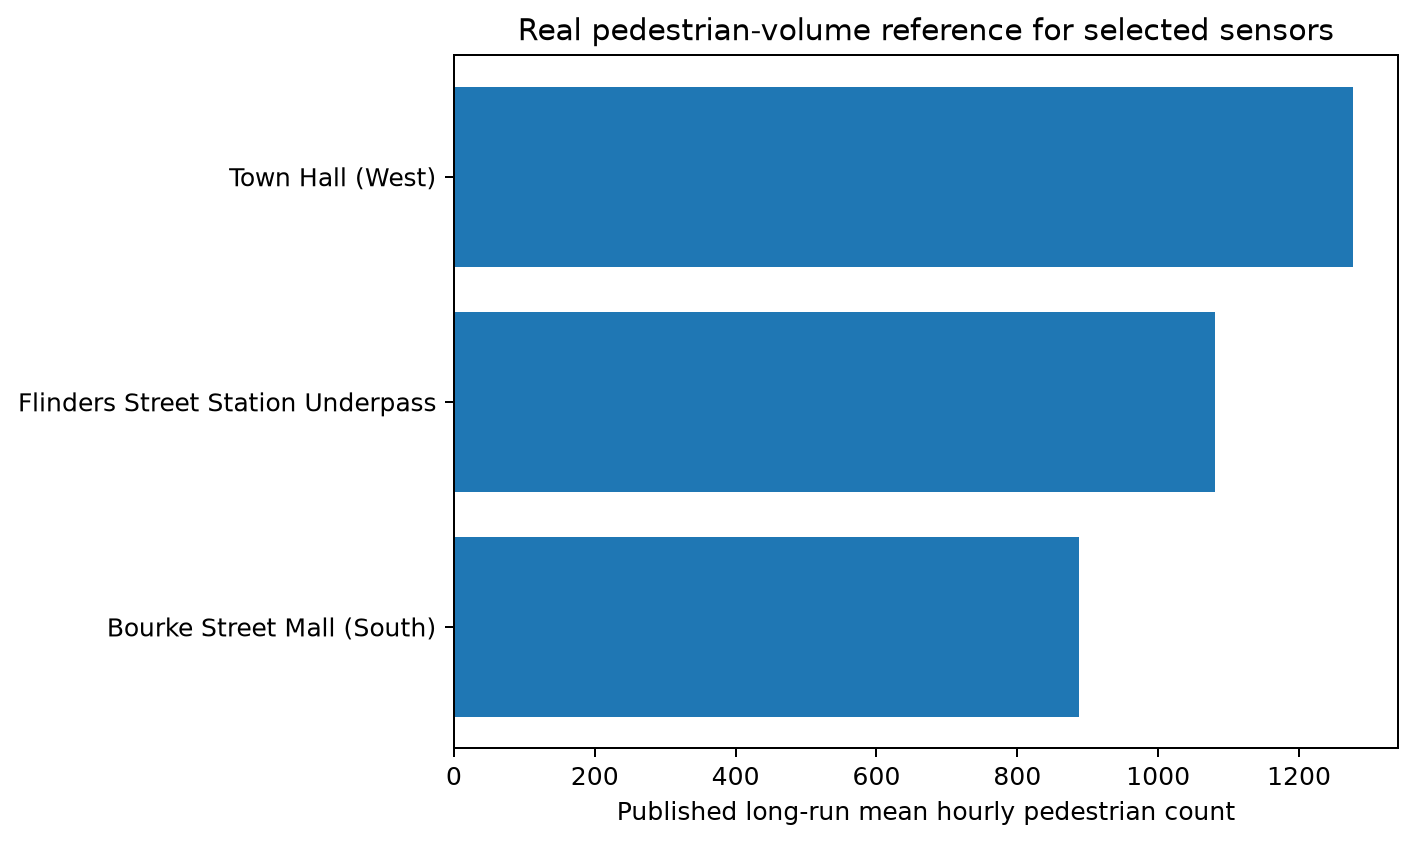

In [6]:
sensor_ref_path = FIG_DIR / 'real_case_sensor_reference.png'
plot_sensor_reference(sensor_stats, sensor_ref_path)
display(Image(filename=str(sensor_ref_path), width=720))

# Supplement Real Data with Synthetic Data
Real-world correlations cannot establish whether music venues influence pedestrian traffic or whether both reflect shared urban factors. A controlled synthetic city provides known effects against which to assess the method’s sensitivity to confounding, data errors, and spatial scale.



## 3. Constructing a Synthetic City with Known Ground Truth

Generate a single example in which venues form one central cluster and two secondary clusters, while sensors are distributed across the same urban area. The direct music effect is set to 0.30 by default, with moderate confounding from urban centrality.

In [7]:
demo_venues, demo_sensors = generate_city(
    seed=RANDOM_SEED,
    n_venues=90,
    n_sensors=32,
    effect=0.30,
    confounding=0.35,
    noise_sd=0.25,
)

print(f'Synthetic venues: {len(demo_venues)}')
print(f'Synthetic sensors: {len(demo_sensors)}')
display(demo_sensors[['sensor_id', 'music_density_500m', 'centrality', 'true_music_effect', 'footfall_index']].head(10))

Synthetic venues: 90
Synthetic sensors: 32


,sensor_id,music_density_500m,centrality,true_music_effect,footfall_index
0,0,23.0,0.515602,0.3,0.345529
1,1,0.0,0.154074,0.3,-0.912501
2,2,5.0,0.279121,0.3,-0.051140
3,3,19.0,0.562348,0.3,0.230230
4,4,1.0,0.212374,0.3,-0.540935
5,5,28.0,0.617040,0.3,0.773292
6,6,29.0,0.584610,0.3,0.373983
7,7,2.0,0.275974,0.3,-0.841868
8,8,3.0,0.186646,0.3,-0.755099
9,9,32.0,0.806206,0.3,1.244145


## Visualizing the Spatial Structure of the Synthetic City

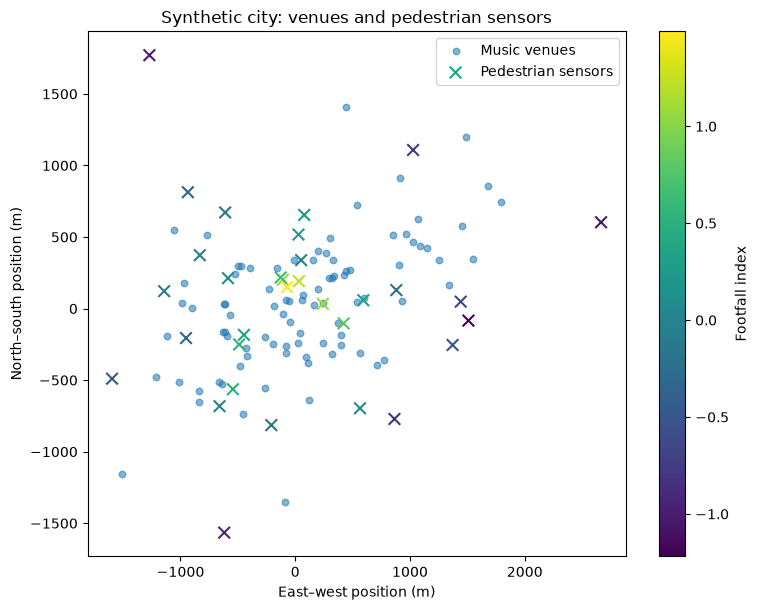

In [8]:
fig, ax = plt.subplots(figsize=(7.8, 6.2))
ax.scatter(demo_venues['x_m'], demo_venues['y_m'], s=22, alpha=0.55, label='Music venues')
sc = ax.scatter(
    demo_sensors['x_m'], demo_sensors['y_m'],
    s=70, marker='x',
    c=demo_sensors['footfall_index'],
    label='Pedestrian sensors'
)
ax.set_title('Synthetic city: venues and pedestrian sensors')
ax.set_xlabel('East–west position (m)')
ax.set_ylabel('North–south position (m)')
ax.legend()
fig.colorbar(sc, ax=ax, label='Footfall index')
fig.tight_layout()
synthetic_map_path = FIG_DIR / 'synthetic_city_structure.png'
fig.savefig(synthetic_map_path, dpi=180, bbox_inches='tight')
plt.show()

## Visualizing the Spatial Association Recovered in the Current Simulation

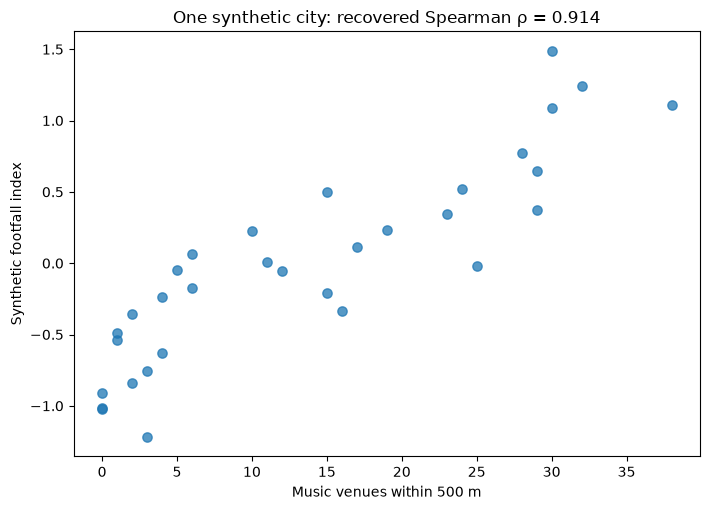

{'rho': 0.9139455079883555,
 'n_sensors': 32,
 'radius_m': 500,
 'coord_noise_m': 0,
 'sensor_keep': 1.0}

In [9]:
single_recovery = recover_association(
    demo_venues, demo_sensors,
    radius_m=500,
    coord_noise_m=0,
    sensor_keep=1.0,
    seed=RANDOM_SEED + 1,
)

rho_single = single_recovery['rho']
fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.scatter(demo_sensors['music_density_500m'], demo_sensors['footfall_index'], s=45, alpha=0.75)
ax.set_xlabel('Music venues within 500 m')
ax.set_ylabel('Synthetic footfall index')
ax.set_title(f'One synthetic city: recovered Spearman ρ = {rho_single:.3f}')
fig.tight_layout()
single_scatter_path = FIG_DIR / 'synthetic_single_association.png'
fig.savefig(single_scatter_path, dpi=180, bbox_inches='tight')
plt.show()

single_recovery

# Simulation Results

In [10]:
simulation_results = run_simulation_lab(replicates=SIM_REPLICATES, seed=RANDOM_SEED)
simulation_summary = summarize_simulations(simulation_results)

simulation_results.to_csv(OUT_DIR / 'simulation_results.csv', index=False)
simulation_summary.to_csv(OUT_DIR / 'simulation_summary.csv', index=False)

print(f'Simulation runs: {len(simulation_results)}')
print(f'Parameter conditions: {len(simulation_summary)}')
display(simulation_summary)

Simulation runs: 630
Parameter conditions: 21


,experiment,level,mean_rho,median_rho,sd_rho,q10_rho,q90_rho,n
0,confounding,0.0,-0.022984,-0.004961,0.170404,-0.318250,0.140519,30
1,confounding,0.2,0.580417,0.583673,0.100890,0.464299,0.731885,30
2,confounding,0.4,0.742798,0.750037,0.102379,0.573267,0.845264,30
3,confounding,0.6,0.845074,0.860571,0.052886,0.770086,0.895000,30
4,coordinate_noise,0.0,0.880929,0.884844,0.045716,0.838029,0.920281,30
5,coordinate_noise,50.0,0.867442,0.880515,0.048323,0.802379,0.912248,30
6,coordinate_noise,100.0,0.857381,0.854225,0.045638,0.799609,0.922949,30
7,coordinate_noise,200.0,0.796842,0.807140,0.061102,0.714335,0.853662,30
8,coverage,0.4,0.851970,0.894854,0.120419,0.719256,0.941846,30
9,coverage,0.6,0.887522,0.888910,0.059805,0.822959,0.955290,30


## When Sensor Coverage Decreases

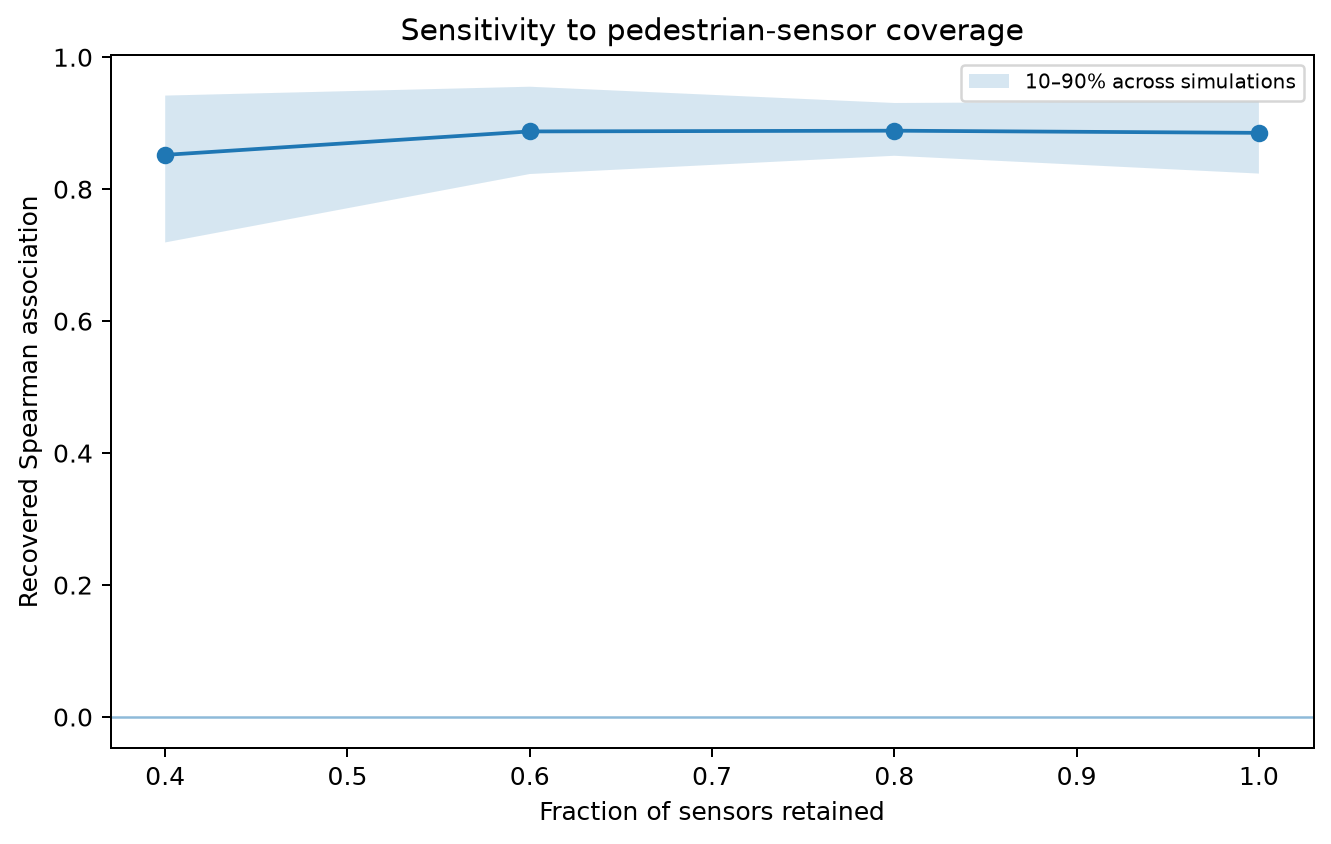

,experiment,level,mean_rho,median_rho,sd_rho,q10_rho,q90_rho,n
8,coverage,0.4,0.851970,0.894854,0.120419,0.719256,0.941846,30
9,coverage,0.6,0.887522,0.888910,0.059805,0.822959,0.955290,30
10,coverage,0.8,0.888627,0.885485,0.035378,0.850621,0.930629,30
11,coverage,1.0,0.885357,0.884982,0.046667,0.823619,0.933248,30


In [11]:
coverage_path = FIG_DIR / 'simulation_coverage.png'
plot_simulation_panel(
    simulation_summary, 'coverage', coverage_path,
    'Fraction of sensors retained'
)
display(Image(filename=str(coverage_path), width=720))
display(simulation_summary.query("experiment == 'coverage'").sort_values('level'))

## Spatial Radius Affects Recovery Quality

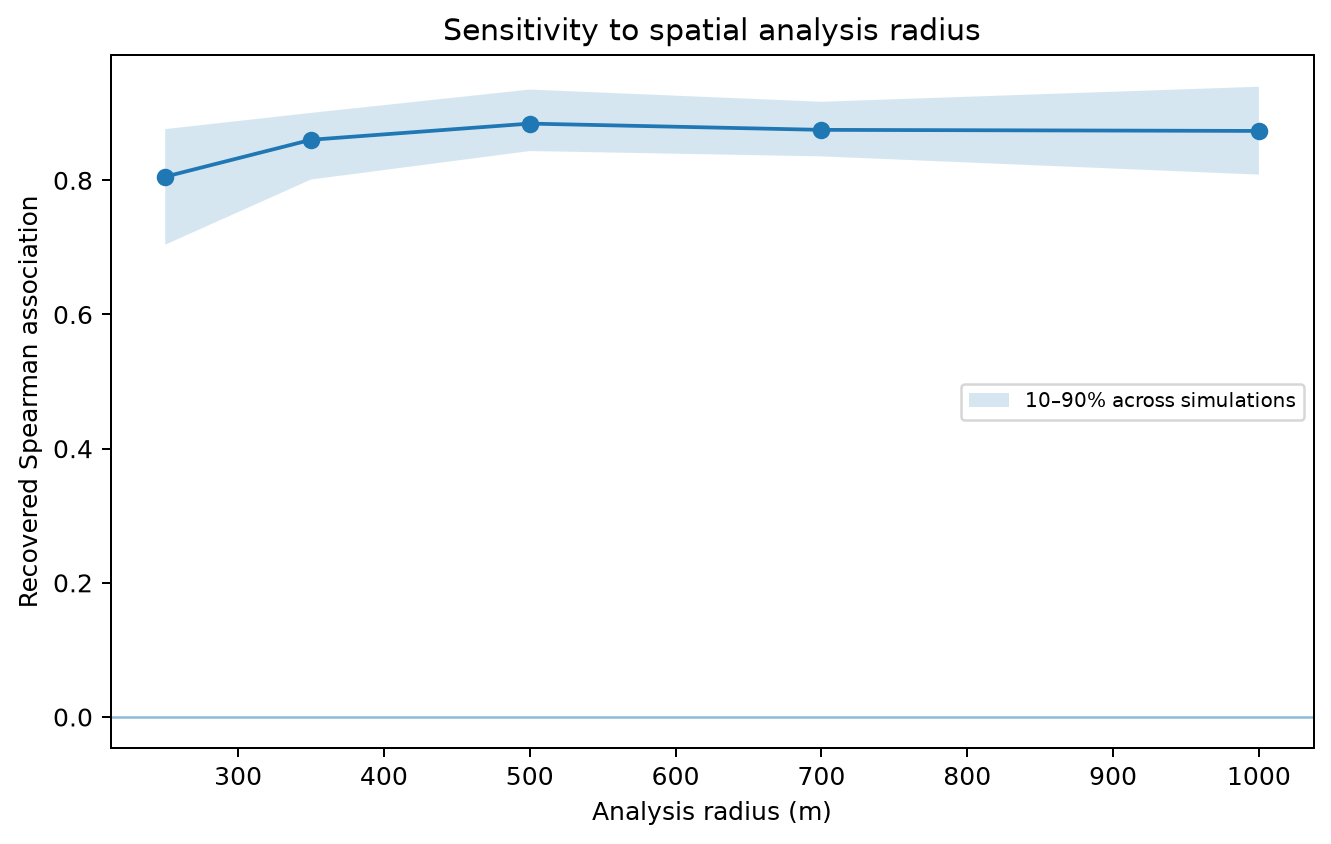

,experiment,level,mean_rho,median_rho,sd_rho,q10_rho,q90_rho,n
16,radius,250.0,0.805393,0.825487,0.068971,0.704003,0.876361,30
17,radius,350.0,0.860466,0.868739,0.039737,0.801202,0.900533,30
18,radius,500.0,0.884580,0.889541,0.039724,0.843653,0.935335,30
19,radius,700.0,0.875239,0.879833,0.039619,0.835721,0.917146,30
20,radius,1000.0,0.873643,0.883223,0.061803,0.808509,0.939559,30


In [12]:
radius_path = FIG_DIR / 'simulation_radius.png'
plot_simulation_panel(
    simulation_summary, 'radius', radius_path,
    'Analysis radius (m)'
)
display(Image(filename=str(radius_path), width=720))
display(simulation_summary.query("experiment == 'radius'").sort_values('level'))

### Location Errors Weaken the Spatial Signal

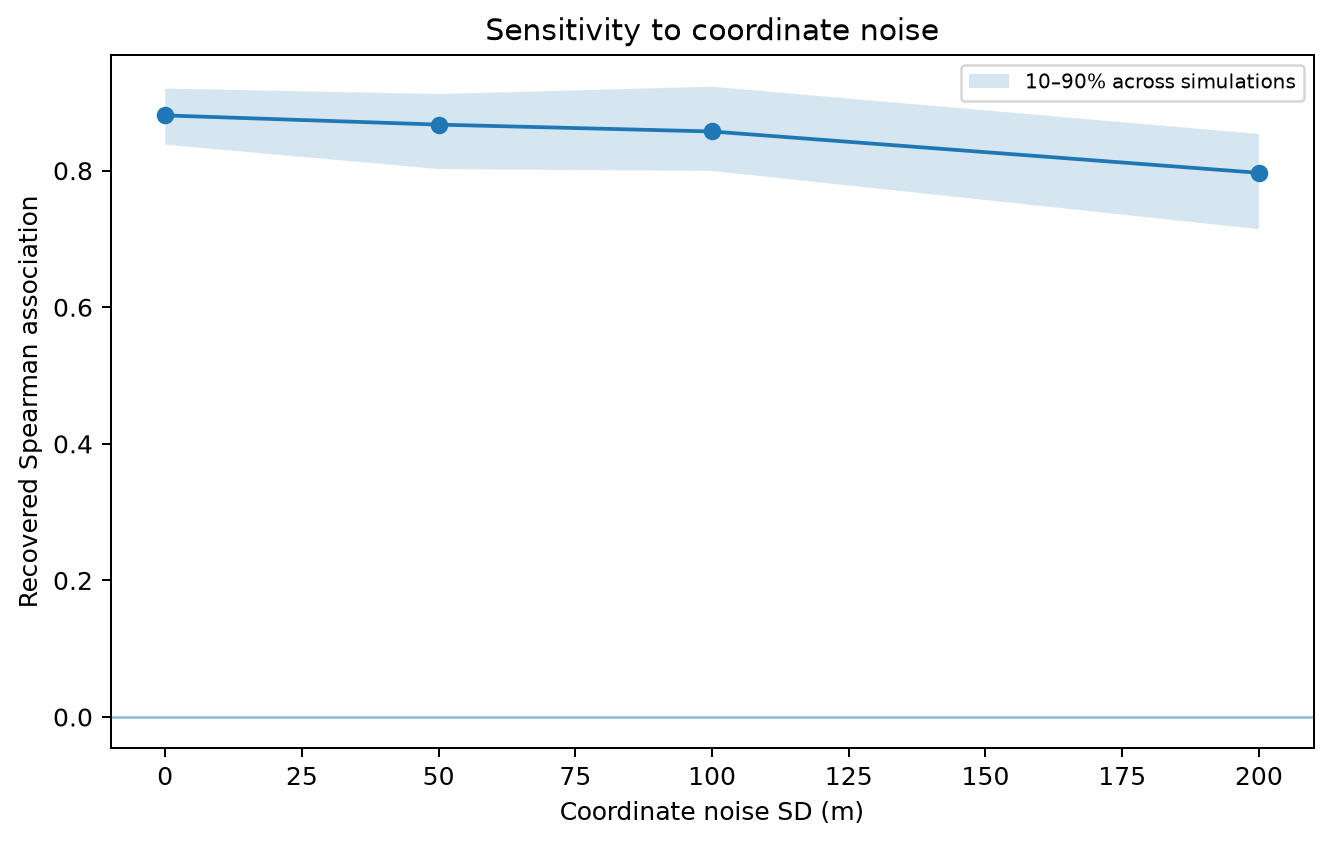

,experiment,level,mean_rho,median_rho,sd_rho,q10_rho,q90_rho,n
4,coordinate_noise,0.0,0.880929,0.884844,0.045716,0.838029,0.920281,30
5,coordinate_noise,50.0,0.867442,0.880515,0.048323,0.802379,0.912248,30
6,coordinate_noise,100.0,0.857381,0.854225,0.045638,0.799609,0.922949,30
7,coordinate_noise,200.0,0.796842,0.807140,0.061102,0.714335,0.853662,30


In [13]:
noise_path = FIG_DIR / 'simulation_coordinate_noise.png'
plot_simulation_panel(
    simulation_summary, 'coordinate_noise', noise_path,
    'Coordinate noise SD (m)'
)
display(Image(filename=str(noise_path), width=720))
display(simulation_summary.query("experiment == 'coordinate_noise'").sort_values('level'))

 ### 8. Shared Urban Centrality Can Generate Apparently Strong Correlations



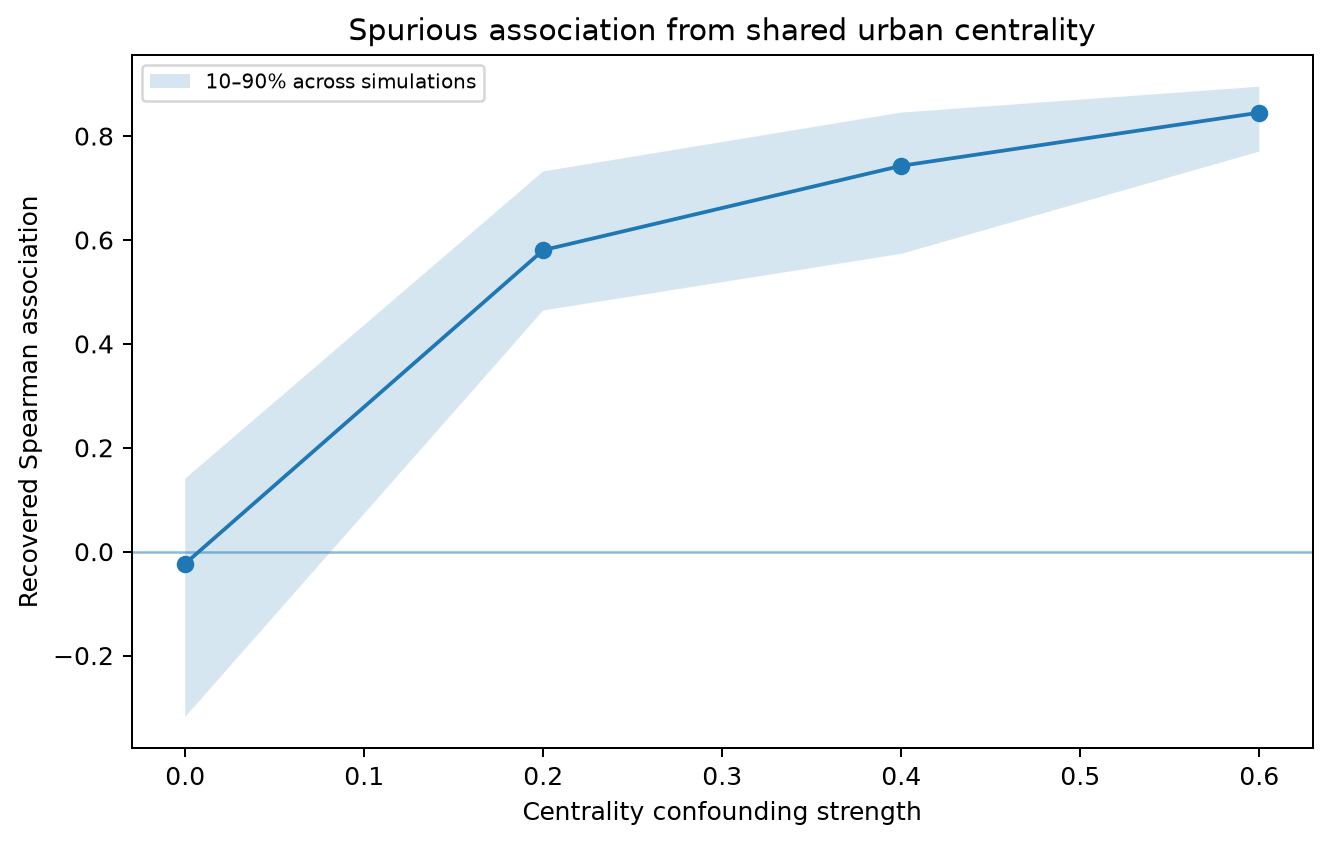

,experiment,level,mean_rho,median_rho,sd_rho,q10_rho,q90_rho,n
0,confounding,0.0,-0.022984,-0.004961,0.170404,-0.318250,0.140519,30
1,confounding,0.2,0.580417,0.583673,0.100890,0.464299,0.731885,30
2,confounding,0.4,0.742798,0.750037,0.102379,0.573267,0.845264,30
3,confounding,0.6,0.845074,0.860571,0.052886,0.770086,0.895000,30


In [14]:
confounding_path = FIG_DIR / 'simulation_confounding.png'
plot_simulation_panel(
    simulation_summary, 'confounding', confounding_path,
    'Centrality confounding strength'
)
display(Image(filename=str(confounding_path), width=720))
conf_table = simulation_summary.query("experiment == 'confounding'").sort_values('level')
display(conf_table)

Gradually increases the direct music effect in the data generator while maintaining moderate confounding from urban centrality. I

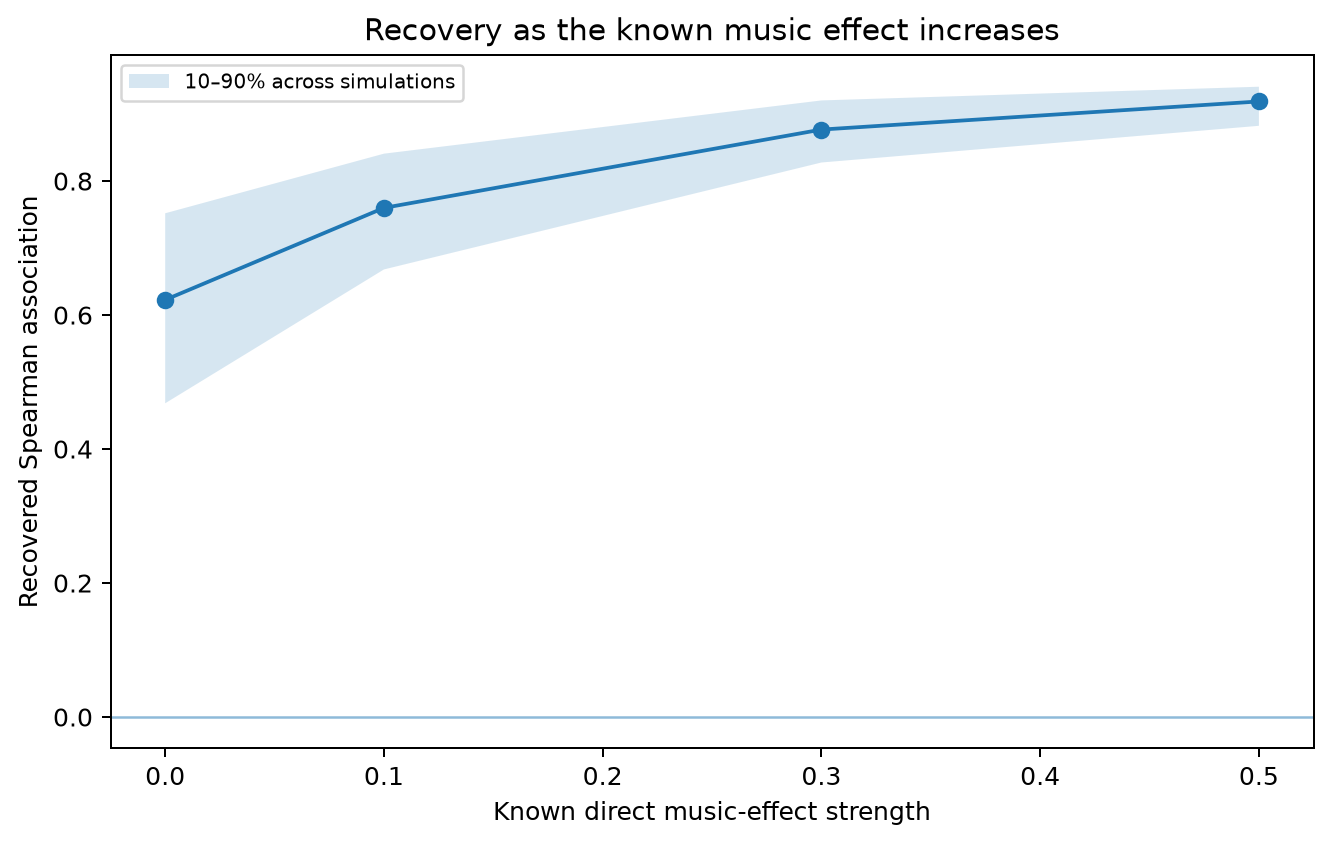

,experiment,level,mean_rho,median_rho,sd_rho,q10_rho,q90_rho,n
12,effect_size,0.0,0.622635,0.640245,0.104864,0.468262,0.751883,30
13,effect_size,0.1,0.759937,0.761991,0.068522,0.668057,0.840877,30
14,effect_size,0.3,0.876849,0.880316,0.033885,0.827693,0.920351,30
15,effect_size,0.5,0.918818,0.925586,0.026196,0.882477,0.940821,30


In [15]:
effect_path = FIG_DIR / 'simulation_effect_size.png'
plot_simulation_panel(
    simulation_summary, 'effect_size', effect_path,
    'Known direct music-effect strength'
)
display(Image(filename=str(effect_path), width=720))
display(simulation_summary.query("experiment == 'effect_size'").sort_values('level'))

In [16]:
def at(exp: str, level: float, col='mean_rho') -> float:
    row = simulation_summary[
        (simulation_summary.experiment == exp)
        & (simulation_summary.level == level)
    ]
    if row.empty:
        return float('nan')
    return float(row.iloc[0][col])


key_findings = pd.DataFrame([
    {
        'question': 'Does a 500 m radius perform well under the current simulation settings?',
        'result': f"mean ρ = {at('radius', 500):.3f}",
        'interpretation': (
            'The 500 m radius yields a relatively high mean recovered correlation '
            'among the candidate radii. Analysis of real data still requires '
            'sensitivity checks across spatial scales.'
        )
    },
    {
        'question': 'How does a 200 m location error affect the results?',
        'result': (
            f"mean ρ: {at('coordinate_noise', 0):.3f} "
            f"→ {at('coordinate_noise', 200):.3f}"
        ),
        'interpretation': (
            'Larger location errors weaken local spatial associations.'
        )
    },
    {
        'question': 'Can a strong correlation arise when the true music effect is zero?',
        'result': (
            f"confounding 0.0: {at('confounding', 0.0):.3f}; "
            f"0.6: {at('confounding', 0.6):.3f}"
        ),
        'interpretation': (
            'Urban centrality, as a shared influence, can generate substantial '
            'apparent correlations. The real-world case study alone therefore '
            'cannot support a causal interpretation.'
        )
    },
    {
        'question': 'Does the method respond to increases in the known direct music effect?',
        'result': (
            f"effect 0.0: {at('effect_size', 0.0):.3f}; "
            f"0.5: {at('effect_size', 0.5):.3f}"
        ),
        'interpretation': (
            'The recovered correlation generally increases with the known effect '
            'size, although the baseline correlation also reflects the centrality '
            'confounding retained in the simulation.'
        )
    },
])

display(key_findings)
key_findings.to_csv(OUT_DIR / 'key_findings.csv', index=False)

,question,result,interpretation
0,Does a 500 m radius perform well under the cur...,mean ρ = 0.885,The 500 m radius yields a relatively high mean...
1,How does a 200 m location error affect the res...,mean ρ: 0.881 → 0.797,Larger location errors weaken local spatial as...
2,Can a strong correlation arise when the true m...,confounding 0.0: -0.023; 0.6: 0.845,"Urban centrality, as a shared influence, can g..."
3,Does the method respond to increases in the kn...,effect 0.0: 0.623; 0.5: 0.919,The recovered correlation generally increases ...
